In [1]:
import os
import sys 
sys.path.append(os.path.dirname("/Users/aborlaff/NASA/EPHESSOS/ephessos"))
import ephessos as ep

2461000.5


In [ ]:
# Trying to read all the NEA elements from the MPCORB.DAT file and ping them to Horizons.
NEA_elements_table = ep.core.read_mpc_nea_file("https://www.minorplanetcenter.net/iau/MPCORB/MPCORB.DAT")

In [2]:
NEA_elements_table = ep.core.read_mpc_nea_file("/Users/aborlaff/NASA/EPHESSOS/notebooks/NEA-test.txt")

i = 0 

from astropy.time import Time
mjd_start = Time('2020-01-01T00:00:00', format='isot', scale='utc').mjd
mjd_end = Time('2026-01-02T00:00:00', format='isot', scale='utc').mjd

#if NEA_elements_table.iloc[i]["Epoch"] == "K25BL":
#    epoch = Time('2025-11-21T00:00:00', format='isot', scale='tt').jd
#    print(epoch)

horizons_dataframe = ep.core.ephessos(epoch=NEA_elements_table.iloc[i]["Epoch"], 
                      eccentricity=NEA_elements_table.iloc[i]["Eccentricity"], 
                      node=NEA_elements_table.iloc[i]["Node"], 
                      arg_perihelion=NEA_elements_table.iloc[i]["Arg_Perihelion"], 
                      inclination=NEA_elements_table.iloc[i]["Inclination"], 
                      mean_anomaly=NEA_elements_table.iloc[i]["Mean_Anomaly"], 
                      semimajor_axis=NEA_elements_table.iloc[i]["Semimajor_Axis"], 
                      mean_motion=NEA_elements_table.iloc[i]["Mean_Motion"], 
                      mjd_start=mjd_start, 
                      mjd_end=mjd_end, 
                      step_size="1d", 
                      verbose=True)

TODO: ping this to https://www.minorplanetcenter.net/iau/MPCORB/MPCORB.DAT
Check tess-ephem! at github
--designation=Default --epoch=K25BL --eccentricity=0.222836 --node=304.27008, --arg_perihelion=178.92978 --inclination=10.82847 --mean_anomaly=310.55432 --semimajor_axis=1.458121 --mean_motion=0.55977529 --mjd_start=58849.0 --mjd_end=61042.0 --step_size=1d
TODO: Implement user-input observer location
TODO: 500@399 is geocentric, make it L2 or user input
TODO: Make it user input optional Quantities!
TODO: Link to the Horizons API docs for the list
TODO: Add H magnitude and G slope parameter to the input
https://ssd.jpl.nasa.gov/api/horizons.api?format=text&COMMAND=';'&OBJECT=Default&EPOCH=2461000.5&ECLIP=J2000&EC=0.222836&OM=304.27008&W=178.92978&IN=10.82847&MA=310.55432&A=1.458121&OBJ_DATA='YES'&MAKE_EPHEM='YES'&EPHEM_TYPE='OBSERVER'&CENTER='500@399'&START_TIME='2020-01-01T00:00:00.000'&STOP_TIME='2026-01-02T00:00:00.000'&STEP_SIZE='1d'&CSV_FORMAT='YES'&QUANTITIES='1,2,3,4,5,6,7,8,9,1

In [3]:
horizons_dataframe

,Date__(UT)__HR:MN,,,R.A._(ICRF),DEC__(ICRF),R.A.__(a-app),DEC_(a-app),dRA*cosD,d(DEC)/dt,Azi_(a-app),...,S-T-O,T-O-M,MN_Illu%,PsAng,PsAMV,Cnst,,RA_deg_ICRF,DEC_deg_ICRF,MJD
0,2020-Jan-01 00:00,,,19 58 28.55,-20 15 08.8,19 59 36.04,-20 11 55.5,85.08477,24.07906,n.a.,...,9.7618,48.5,29.9567,77.457,247.588,Sgr,,299.618958,-20.252444,58849.0
1,2020-Jan-02 00:00,,,20 00 53.61,-20 05 30.8,20 02 00.98,-20 02 14.0,85.03368,24.38496,n.a.,...,9.5334,59.7,38.9224,77.071,247.379,Sgr,,300.223375,-20.091889,58850.0
2,2020-Jan-03 00:00,,,20 03 18.43,-19 55 45.4,20 04 25.68,-19 52 25.1,84.98213,24.68907,n.a.,...,9.3050,71.0,48.2636,76.676,247.173,Sgr,,300.826792,-19.929278,58851.0
3,2020-Jan-04 00:00,,,20 05 43.01,-19 45 52.7,20 06 50.14,-19 42 28.9,84.93029,24.99138,n.a.,...,9.0766,82.3,57.7219,76.274,246.969,Sgr,,301.429208,-19.764639,58852.0
4,2020-Jan-05 00:00,,,20 08 07.36,-19 35 52.7,20 09 14.37,-19 32 25.5,84.87831,25.29187,n.a.,...,8.8481,93.7,67.0270,75.863,246.767,Cap,,302.030667,-19.597972,58853.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2189,2025-Dec-29 00:00,,,01 13 41.54,+32 16 55.1,01 15 08.83,+32 25 23.4,76.29442,-37.3631,n.a.,...,50.3721,20.4,63.3920,74.935,227.608,Psc,,18.423083,32.281972,61038.0
2190,2025-Dec-30 00:00,,,01 16 07.67,+32 02 05.2,01 17 35.12,+32 10 31.6,78.27136,-36.9464,n.a.,...,50.7270,19.1,74.0229,74.678,228.270,Psc,,19.031958,32.034778,61039.0
2191,2025-Dec-31 00:00,,,01 18 37.10,+31 47 25.2,01 20 04.71,+31 55 49.6,80.20811,-36.5453,n.a.,...,51.0755,26.4,83.5836,74.440,228.961,Psc,,19.654583,31.790333,61040.0
2192,2026-Jan-01 00:00,,,01 21 09.74,+31 32 54.7,01 22 37.53,+31 41 17.1,82.10512,-36.1612,n.a.,...,51.4177,37.9,91.3988,74.220,229.681,Psc,,20.290583,31.548528,61041.0


In [4]:


eros_horizons_dataframe = ep.core.ephessos(designation="00433", epoch="K25BL",
                      mjd_start=mjd_start, 
                      mjd_end=mjd_end, 
                      step_size="1d", 
                      verbose=True)

print(eros_horizons_dataframe)

TODO: ping this to https://www.minorplanetcenter.net/iau/MPCORB/MPCORB.DAT
Check tess-ephem! at github
--designation=00433 --epoch=K25BL --eccentricity=None --node=None, --arg_perihelion=None --inclination=None --mean_anomaly=None --semimajor_axis=None --mean_motion=None --mjd_start=58849.0 --mjd_end=61042.0 --step_size=1d
TODO: Implement user-input observer location
TODO: 500@399 is geocentric, make it L2 or user input
TODO: Make it user input optional Quantities!
TODO: Link to the Horizons API docs for the list
TODO: Add H magnitude and G slope parameter to the input
https://ssd.jpl.nasa.gov/api/horizons.api?format=text&COMMAND='00433'&OBJECT=00433&EPOCH=2461000.5&ECLIP=J2000&OBJ_DATA='YES'&MAKE_EPHEM='YES'&EPHEM_TYPE='OBSERVER'&CENTER='500@399'&START_TIME='2020-01-01T00:00:00.000'&STOP_TIME='2026-01-02T00:00:00.000'&STEP_SIZE='1d'&CSV_FORMAT='YES'&QUANTITIES='1,2,3,4,5,6,7,8,9,10,19,20,23,24,25,27,29'
['2020-01-01 00:00' '2020-01-02 00:00' '2020-01-03 00:00' ...
 '2025-12-31 00:00' 

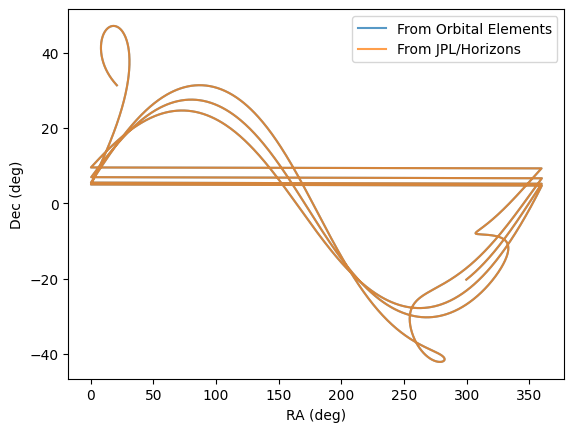

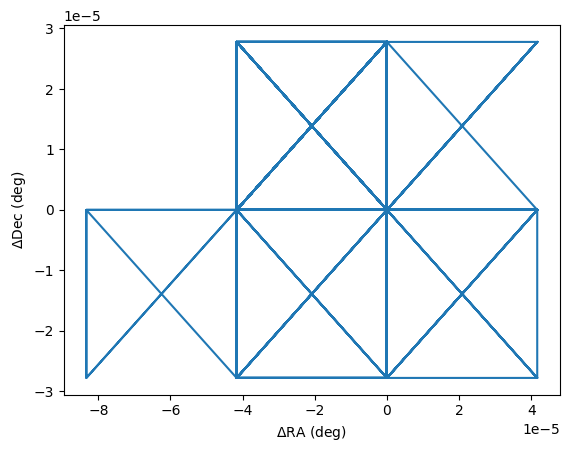

In [5]:
import matplotlib.pyplot as plt
plt.plot(horizons_dataframe["RA_deg_ICRF"], horizons_dataframe["DEC_deg_ICRF"], alpha=0.75, label="From Orbital Elements")
plt.plot(eros_horizons_dataframe["RA_deg_ICRF"], eros_horizons_dataframe["DEC_deg_ICRF"], alpha=0.75, label="From JPL/Horizons")
plt.xlabel("RA (deg)")
plt.ylabel("Dec (deg)")
plt.legend() 
plt.savefig("horizons_vs_elements_comparison.png", dpi=300)
plt.show()


plt.plot(horizons_dataframe["RA_deg_ICRF"] - eros_horizons_dataframe["RA_deg_ICRF"], horizons_dataframe["DEC_deg_ICRF"] - eros_horizons_dataframe["DEC_deg_ICRF"])
plt.xlabel(r'$\Delta$RA (deg)')
plt.ylabel(r'$\Delta$Dec (deg)') 
plt.savefig("horizons_vs_elements_comparison_delta.png", dpi=300)
plt.show()


In [7]:
4E-5*60*60

0.14400000000000002